# Task 1: EV Charging Demand Forecasting

## Approach: Prophet

In this task, historical EV charging data will be analysed to identify demand patterns and forecast future charging demand. The Prophet forecasting model will be used to capture trends and seasonal patterns and predict future charging demand.

In [1]:
import pandas as pd

# Load the EV charging sessions data
file_path = "ev_charging_dataset.xlsx"

sessions = pd.read_excel(file_path, sheet_name="sessions")

# Convert timestamp to datetime
sessions["start_timestamp"] = pd.to_datetime(sessions["start_timestamp"])

# Check the dataset
print("Dataset shape:", sessions.shape)
print("\nColumns:")
print(sessions.columns.tolist())

print("\nMissing values:")
print(sessions.isnull().sum())

print("\nFirst 5 rows:")
display(sessions.head())

Dataset shape: (294024, 15)

Columns:
['session_id', 'station_id', 'charger_id', 'charger_type', 'start_timestamp', 'end_timestamp', 'session_duration_minutes', 'energy_kwh', 'price_per_kwh', 'total_cost', 'payment_method', 'user_type', 'customer_id', 'station_region', 'year']

Missing values:
session_id                  0
station_id                  0
charger_id                  0
charger_type                0
start_timestamp             0
end_timestamp               0
session_duration_minutes    0
energy_kwh                  0
price_per_kwh               0
total_cost                  0
payment_method              0
user_type                   0
customer_id                 0
station_region              0
year                        0
dtype: int64

First 5 rows:


,session_id,station_id,charger_id,charger_type,start_timestamp,end_timestamp,session_duration_minutes,energy_kwh,price_per_kwh,total_cost,payment_method,user_type,customer_id,station_region,year
0,S_00000001,STN_001,STN_001_CH_02,DC_150kW,2022-01-01 08:30:00,2022-01-01 08:56:00,26,56.9,0.47,26.74,app,fleet,CUST_00134,North West,2022
1,S_00000002,STN_001,STN_001_CH_02,DC_150kW,2022-01-01 09:20:00,2022-01-01 09:41:00,21,40.7,0.46,18.72,app,delivery,CUST_00195,North West,2022
2,S_00000003,STN_001,STN_001_CH_04,DC_50kW,2022-01-01 09:00:00,2022-01-01 09:48:00,48,30.9,0.47,14.52,rfid,public,CUST_01935,North West,2022
3,S_00000004,STN_001,STN_001_CH_01,DC_50kW,2022-01-01 23:20:00,2022-01-02 00:01:00,41,28.4,0.45,12.78,rfid,public,CUST_00036,North West,2022
4,S_00000005,STN_001,STN_001_CH_01,DC_50kW,2022-01-01 16:10:00,2022-01-01 17:00:00,50,31.7,0.56,17.75,rfid,taxi,CUST_00011,North West,2022


In [2]:
# Create daily charging demand
daily_demand = (
    sessions
    .set_index("start_timestamp")
    .resample("D")["energy_kwh"]
    .sum()
    .reset_index()
)

# Rename columns for Prophet
daily_demand = daily_demand.rename(columns={
    "start_timestamp": "ds",
    "energy_kwh": "y"
})

print("Daily demand shape:", daily_demand.shape)
display(daily_demand.head())

Daily demand shape: (1096, 2)


,ds,y
0,2022-01-01,5024.4
1,2022-01-02,3861.3
2,2022-01-03,6250.3
3,2022-01-04,5620.4
4,2022-01-05,6104.1


In [4]:
from prophet import Prophet

C:\Users\goury\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from prophet import Prophet

model = Prophet()
model.fit(daily_demand)

19:25:23 - cmdstanpy - INFO - Chain [1] start processing
19:25:24 - cmdstanpy - INFO - Chain [1] done processing


In [6]:
# Create future dates for forecasting
future = model.make_future_dataframe(periods=365)

print("Future dataset shape:", future.shape)
display(future.tail())

Future dataset shape: (1461, 1)


,ds
1456,2025-12-27
1457,2025-12-28
1458,2025-12-29
1459,2025-12-30
1460,2025-12-31


In [7]:
forecast = model.predict(future)

print("Forecast shape:", forecast.shape)

display(
    forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(365)
)

Forecast shape: (1461, 19)


,ds,yhat,yhat_lower,yhat_upper
1096,2025-01-01,26185.141829,24575.843918,27817.004216
1097,2025-01-02,26572.615341,24946.573224,28230.747014
1098,2025-01-03,27054.746665,25427.796091,28707.835509
1099,2025-01-04,23773.342236,22151.882545,25471.570776
1100,2025-01-05,24162.842259,22416.683833,25828.509129
...,...,...,...,...
1456,2025-12-27,27560.237963,25167.501610,30156.919701
1457,2025-12-28,27957.125529,25437.393842,30695.077444
1458,2025-12-29,31989.329894,29709.000315,34576.750324
1459,2025-12-30,32437.338633,30097.439882,35023.094101


In [8]:
# Use the last 30 days of historical data as the test set
train = daily_demand.iloc[:-30].copy()
test = daily_demand.iloc[-30:].copy()

print("Training data:", train.shape)
print("Test data:", test.shape)
print("\nTest period:")
print(test["ds"].min(), "to", test["ds"].max())

Training data: (1066, 2)
Test data: (30, 2)

Test period:
2024-12-02 00:00:00 to 2024-12-31 00:00:00


In [9]:
# Train Prophet on the training dataset

from prophet import Prophet

test_model = Prophet()
test_model.fit(train)

print("Prophet model trained successfully on the training data.")

19:27:22 - cmdstanpy - INFO - Chain [1] start processing
19:27:22 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully on the training data.


In [10]:
# Generate predictions for the test period

test_forecast = test_model.predict(test[["ds"]])

print("Test forecast shape:", test_forecast.shape)

display(
    test_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]
)

Test forecast shape: (30, 19)


,ds,yhat,yhat_lower,yhat_upper
0,2024-12-02,21948.383444,20326.210703,23540.683090
1,2024-12-03,21843.431016,20325.264047,23444.160239
2,2024-12-04,21745.571778,20279.632894,23318.028675
3,2024-12-05,21630.038448,20119.584242,23173.785848
4,2024-12-06,21599.230720,19862.458147,23331.994563
5,2024-12-07,17886.678309,16291.525648,19504.697194
6,2024-12-08,17831.477007,16260.170100,19326.904379
7,2024-12-09,21329.841005,19604.106050,22820.855684
8,2024-12-10,21259.806691,19677.254501,22822.396228
9,2024-12-11,21218.526688,19581.795878,22811.455892


In [11]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

# Compare actual vs predicted demand
actual = test["y"].values
predicted = test_forecast["yhat"].values

# Calculate evaluation metrics
mape = mean_absolute_percentage_error(actual, predicted) * 100
rmse = np.sqrt(mean_squared_error(actual, predicted))

print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f} kWh")

MAPE: 8.29%
RMSE: 2061.55 kWh


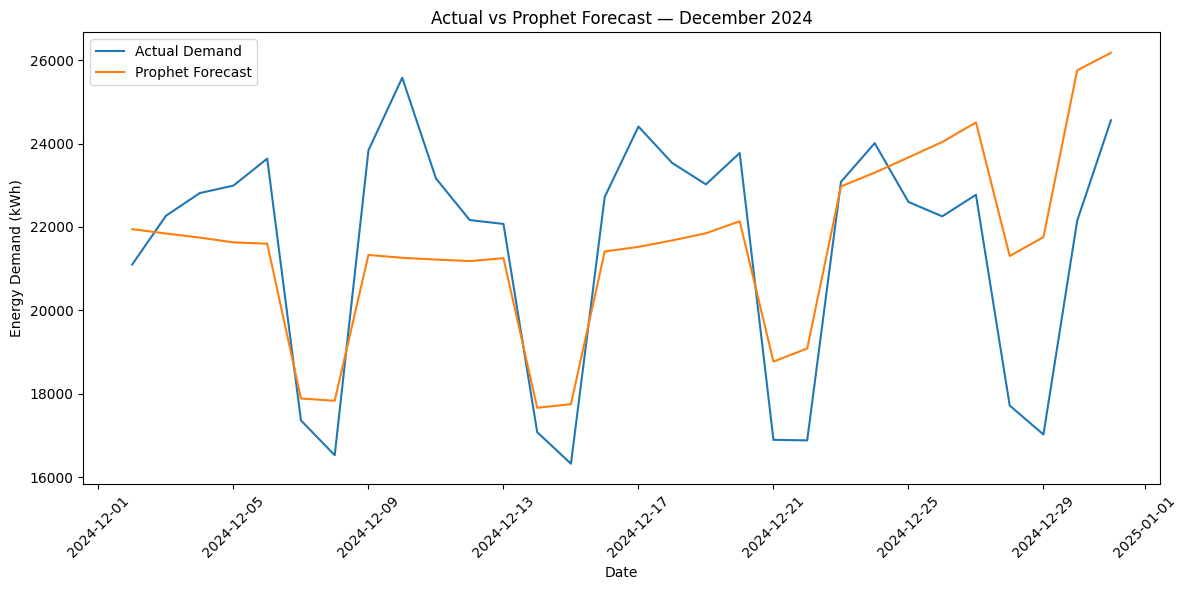

In [12]:
import matplotlib.pyplot as plt

# Plot actual vs predicted demand
plt.figure(figsize=(12, 6))

plt.plot(test["ds"], test["y"], label="Actual Demand")
plt.plot(test_forecast["ds"], test_forecast["yhat"], label="Prophet Forecast")

plt.xlabel("Date")
plt.ylabel("Energy Demand (kWh)")
plt.title("Actual vs Prophet Forecast — December 2024")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

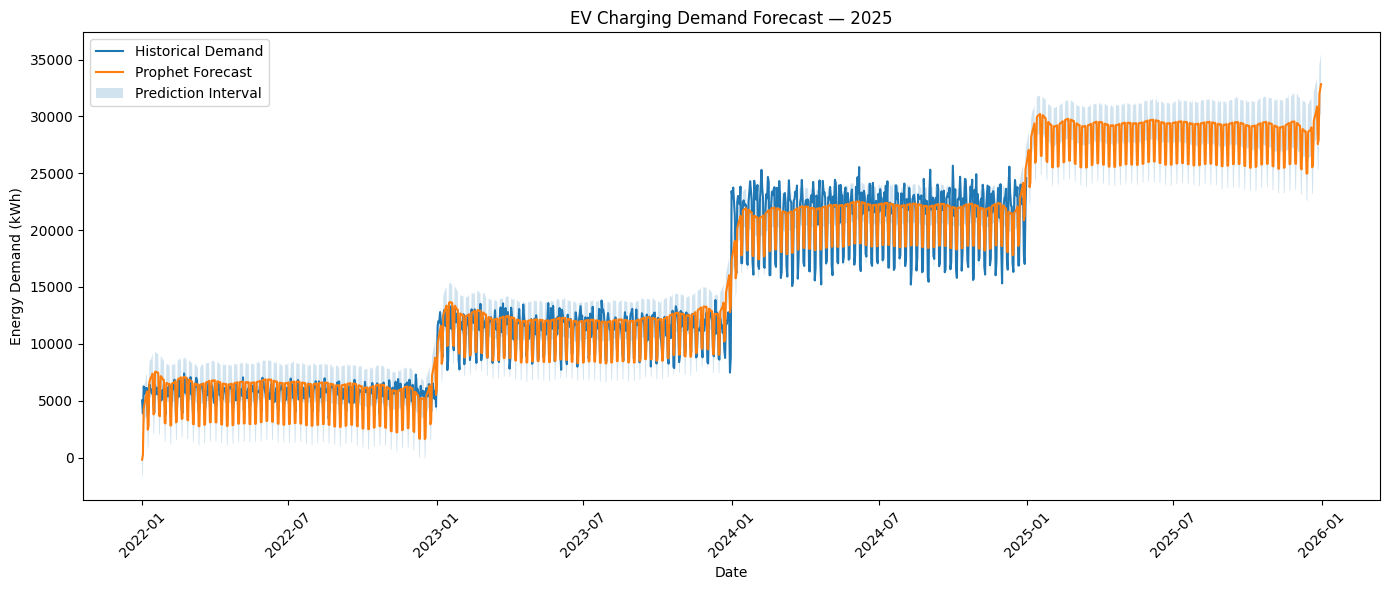

In [13]:
# Plot the 365-day Prophet forecast

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    daily_demand["ds"],
    daily_demand["y"],
    label="Historical Demand"
)

plt.plot(
    forecast["ds"],
    forecast["yhat"],
    label="Prophet Forecast"
)

plt.fill_between(
    forecast["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    alpha=0.2,
    label="Prediction Interval"
)

plt.xlabel("Date")
plt.ylabel("Energy Demand (kWh)")
plt.title("EV Charging Demand Forecast — 2025")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [14]:
# Extract key forecast insights

forecast_2025 = forecast[forecast["ds"].dt.year == 2025].copy()

max_day = forecast_2025.loc[forecast_2025["yhat"].idxmax()]
min_day = forecast_2025.loc[forecast_2025["yhat"].idxmin()]

print("2025 Forecast Insights")
print("-" * 40)

print(
    f"Highest predicted demand: {max_day['yhat']:.2f} kWh "
    f"on {max_day['ds'].date()}"
)

print(
    f"Lowest predicted demand: {min_day['yhat']:.2f} kWh "
    f"on {min_day['ds'].date()}"
)

print(
    f"Average predicted daily demand: "
    f"{forecast_2025['yhat'].mean():.2f} kWh"
)

print(
    f"Forecast range: "
    f"{forecast_2025['yhat'].min():.2f} – "
    f"{forecast_2025['yhat'].max():.2f} kWh"
)

2025 Forecast Insights
----------------------------------------
Highest predicted demand: 32835.30 kWh on 2025-12-31
Lowest predicted demand: 23773.34 kWh on 2025-01-04
Average predicted daily demand: 28353.35 kWh
Forecast range: 23773.34 – 32835.30 kWh


## Key Insights & Conclusion

- The Prophet model achieved a **MAPE of 8.29%** and an **RMSE of 2,061.55 kWh** on the 30-day test period.
- The model captured the recurring weekly pattern in EV charging demand, with lower predicted demand on weekends and higher demand during weekdays.
- For 2025, the predicted average daily charging demand is approximately **28,353.35 kWh**.
- The forecasted daily demand ranges from approximately **23,773.34 kWh to 32,835.30 kWh**.
- The highest predicted demand is **32,835.30 kWh on December 31, 2025**.
- The lowest predicted demand is **23,773.34 kWh on January 4, 2025**.
- The forecast indicates an overall upward trend in charging demand throughout 2025.

### Business Implications

The forecast can help PowerGrid plan charger capacity, energy requirements, maintenance schedules, and operational resources in advance. Higher-demand periods can be prioritised for capacity planning, while lower-demand periods may provide opportunities for maintenance and operational adjustments.

### Conclusion

Prophet provides a useful time-series forecasting approach for predicting future EV charging demand. With a MAPE of 8.29%, the model demonstrates reasonable forecasting accuracy and can support short- and long-term EV infrastructure planning.